# N1 · 三种 VL 连接器对比 (Three Connectors)

> 配套 10.2-L1/L2/L4 · 跑三种连接器, 对比输出序列长度 (cross-attn 不增长!),
> 改视觉 token 数看差异, 用决策树给场景选路线。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
VIS_SRC = Path.cwd().parent.parent / "vision-encoders" / "src"  # 复用 10.1 mini-ViT
for p in (SRC, VIS_SRC): sys.path.insert(0, str(p))
import torch, pandas as pd
import connectors as cn
print('connectors 就绪')

connectors 就绪


## 1. 三路线定性对比表 (L1)

In [2]:
pd.DataFrame(cn.param_comparison())

,connector,视觉占输入序列,参数量,改 LLM 结构,优点,缺点
0,projection (LLaVA),是 (+16 token),小 (一个 MLP),否,"最简单, 效果好, 训练快",视觉吃上下文; 高分辨率 token 爆炸
1,cross_attn (Flamingo),"否 (压成 4, cross-attn 注入)",中 (resampler+cross 层),是 (插 cross-attn 层),视觉不占上下文; 可处理多图/视频,"改 LLM 结构, 实现复杂"
2,early_fusion (Chameleon),是 (同质 token),极小 (一个 embed),否 (但需从头训),"架构统一, 利于理解+生成一体","通常需从头训, 不能复用纯文本 LLM"


## 2. 前向: 同样输入 (16 视觉 + 10 文本), 三种连接器输出序列长度

In [3]:
torch.manual_seed(0)
conns = cn.build_connectors(vis_dim=32, llm_dim=48, n_vis=16)
vis = torch.randn(2, 16, 32)   # 来自 10.1 ViT 的视觉 token
txt = torch.randn(2, 10, 48)
for name, m in conns.items():
    out = m(vis, txt)
    print(f"  {name:14}: 输出序列长 {out.shape[1]}  {'(视觉占序列)' if out.shape[1]>10 else '(视觉不占序列, cross-attn 注入)'}")

  projection    : 输出序列长 26  (视觉占序列)
  cross_attn    : 输出序列长 10  (视觉不占序列, cross-attn 注入)
  early_fusion  : 输出序列长 26  (视觉占序列)


## 3. 关键差异: 视觉 token 增多时, 谁的序列会爆? (L2 vs L3)

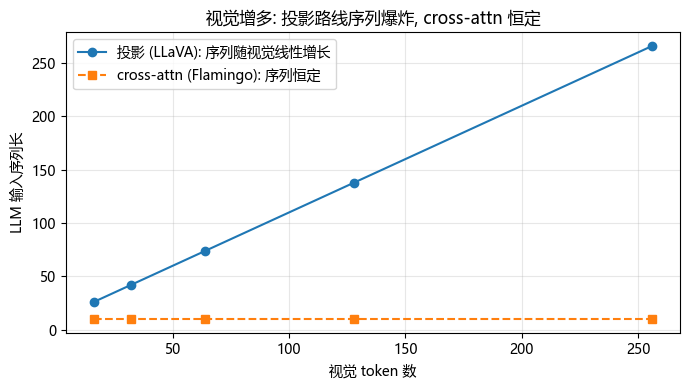

→ 这就是 L2 说的: 高分辨率/多图时, 投影撑爆上下文, cross-attn 不变。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import numpy as np
nvis_list = [16, 32, 64, 128, 256]
proj_len, cross_len = [], []
for nv in nvis_list:
    c = cn.build_connectors(vis_dim=32, llm_dim=48, n_vis=nv)
    v = torch.randn(1, nv, 32); t = torch.randn(1, 10, 48)
    proj_len.append(c['projection'](v, t).shape[1])
    cross_len.append(c['cross_attn'](v, t).shape[1])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(nvis_list, proj_len, 'o-', label='投影 (LLaVA): 序列随视觉线性增长')
ax.plot(nvis_list, cross_len, 's--', label='cross-attn (Flamingo): 序列恒定')
ax.set_xlabel('视觉 token 数'); ax.set_ylabel('LLM 输入序列长'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('视觉增多: 投影路线序列爆炸, cross-attn 恒定')
plt.tight_layout(); plt.show()
print('→ 这就是 L2 说的: 高分辨率/多图时, 投影撑爆上下文, cross-attn 不变。')

## 4. 用决策树选路线 (L4)

In [5]:
scenarios = {
    "单图问答 (单卡快速起步)": "投影 (LLaVA) — 最简, 复用现成 LLM",
    "视频理解 (上百帧)": "cross-attn (Flamingo) — resampler 压缩, 不爆上下文",
    "文生图 / any-to-any": "early-fusion (Chameleon) — 统一 token 才能自回归画图",
}
for s, choice in scenarios.items():
    print(f"  {s:24} → {choice}")
print("\n→ 没有最好, 只有适配约束 (先问: 要生成? 多图? 算力?)。")

  单图问答 (单卡快速起步)            → 投影 (LLaVA) — 最简, 复用现成 LLM
  视频理解 (上百帧)               → cross-attn (Flamingo) — resampler 压缩, 不爆上下文
  文生图 / any-to-any         → early-fusion (Chameleon) — 统一 token 才能自回归画图

→ 没有最好, 只有适配约束 (先问: 要生成? 多图? 算力?)。


## 5. 反思
你看清了三路线的核心差异 (视觉占不占序列 / 改不改 LLM) 和决策逻辑。
下一步 N2: 真搭一个投影路线的 mini-LLaVA, 把 10.1 的 ViT 接到 tiny LLM。